In [1]:
import numpy as np
import yaml
import torch
import xarray as xr
import os

In [2]:
os.getcwd()

'/beegfs/home/d.akhmetov/unsuperv_seism/contrast_learn/src_3d_no_intersect'

In [3]:
def read_optim_config(config_path):
    with open(config_path) as fh:
        config = yaml.load(fh, Loader=yaml.FullLoader)
    return config
config_path = r'/trinity/home/d.akhmetov/unsuperv_seism/contrast_learn/configs/ae3d_debug.yaml'

config = read_optim_config(config_path)
config['sweep_name'] = 'feaf8'

In [4]:
from main import main

/beegfs/home/d.akhmetov/unsuperv_seism/seism_segm_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Random seed set as 228


In [5]:
main(config)

Folder '../../results/no_overlap_3d/feaf8' created successfully.
Read cubes using mmap...
Took 2 attributes, 
 Namely: ['Cube_2019_SUMM_horzn_down.npy', 'Cube_2019_15Hz_horzn_down.npy']
Cubes has been read successfully!
Attribute shapes: (2, 741, 707, 239)
Start checking data shapes
Min-max normalization strategy was taken!
min: -61426.801, max: 61832.496 for Cube_2019_SUMM_horzn_down.npy
mean: 289.036, std: 6907.842 for Cube_2019_SUMM_horzn_down.npy

min: 0.000, max: 2629.082 for Cube_2019_15Hz_horzn_down.npy
mean: 364.605, std: 290.722 for Cube_2019_15Hz_horzn_down.npy

Cubes has been normalized successfully!
Single-target hyperparam optimizatios is picked! MSE
Optuna targets ['MSE'] has been taken


[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs-legacy.neptune.ai/logging/source_code/


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/Facies-clustering/unsuperv-seism/e/UN-66


/beegfs/home/d.akhmetov/unsuperv_seism/seism_segm_env/lib/python3.12/site-packages/neptune/internal/utils/git.py:71: UserWarning: GitPython could not be initialized
  warnings.warn("GitPython could not be initialized")
/beegfs/home/d.akhmetov/unsuperv_seism/contrast_learn/src_3d_no_intersect/utils.py:66: ExperimentalWarning: BruteForceSampler is experimental (supported from v3.1.0). The interface can change in the future.
  sampler = sampler_class(*args, **kwargs)
[I 2026-02-24 19:17:18,865] A new study created in memory with name: no-name-e876d1de-926d-444e-bf81-d8a55e867917


Sampler imported successfully!
Device: cpu
Encoder:
Dropout_rate: 0.05, conv_layers: 4, base_filts: 6

Decoder:
Dropout_rate: 0.18, conv_layers: 4, base_filts: 6
Encoder flattened size: 48
Decoder initial linear size: 1296
Decoder initial spatial dims: (3, 3, 3)
Created 3D VAE for input shape: (2, 33, 33, 10)
Latent dimension: 16
Total parameters: 51,296
Warmup epchs for B is constant: 1 for all runs.
Configuration with no intersection picked
Total possible patches: 10626
Dataset initialized with 3116 valid patches
Patch size: (33, 33, 10), Stride: (33, 33, 10)
Train size: 2492, Test size: 624
len train dataset 2492


...

/beegfs/home/d.akhmetov/unsuperv_seism/seism_segm_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Latent vecs shape: (3116, 16)
Extracted 3116 latent vectors of dimension 16
Fitting GMM with 5 clusters...
Cluster sizes: {np.int64(0): np.int64(1430), np.int64(1): np.int64(155), np.int64(2): np.int64(1057), np.int64(3): np.int64(64), np.int64(4): np.int64(410)}
Computing t-SNE...
t-SNE visualization saved and logged to Neptune
Creating clustered volume...
Volume cluster distribution: {np.int32(-1): np.int64(5123311), np.int32(0): np.int64(15349069), np.int32(1): np.int64(1651163), np.int32(2): np.int64(11390328), np.int32(3): np.int64(660404), np.int32(4): np.int64(4427629)}


[I 2026-02-24 19:17:41,113] Trial 0 finished with value: 0.15273497253656387 and parameters: {}. Best is trial 0 with value: 0.15273497253656387.


Clustered volume saved to: ../../results/no_overlap_3d/feaf8/cubes/clustered_volume_trial_0.npy
Metadata saved to: ../../results/no_overlap_3d/feaf8/cubes/clustered_volume_trial_0_metadata.yaml


StopIteration: 

In [7]:
model_conf = r'/trinity/home/d.akhmetov/unsuperv_seism/results/no_overlap_3d/feaf1/weights/model_config_0.yaml' 

In [8]:
config = read_optim_config(model_conf)

In [10]:
import xarray as xr

In [12]:
xarr_path = r'/trinity/home/d.akhmetov/unsuperv_seism/data/downsamp_cubes_4times/Cube_2019_15Hz_horzn_down.nc'

In [13]:
xarr = xr.load_dataset(xarr_path)

In [2]:
from segysak.segy import segy_writer

In [3]:
import numpy as np
import yaml
import torch
import xarray as xr
import os

In [12]:
def save_segy(results_xr, save_fold, f_name):
    print('Save SEGY')
    results_xr.attrs['coord_scalar'] = 1.00000
    results_xr.attrs['sample_rate'] = 2.0000
    results_xr.attrs['source_file'] = 'Cube_resulting'
    cube_path = os.path.join(save_fold, f'{f_name}.segy')
    # the dictionary with byte location of the coords
    
    # trace_header_map = dict(
    #                 cdp_x=73,
    #                 cdp_y=77)
    # results_xr.seisio.to_segy(
    #         cube_path,
    #         trace_header_map=trace_header_map,
    #         iline=189,
    #             xline=193,
    #     twt=None
    #         )
    trace_header_map = dict(iline=189,
                         xline=193,
                         cdp_x=73,
                         cdp_y=77)
    segy_writer(
            results_xr,
            cube_path,
            trace_header_map=trace_header_map
        )
    
def save_segy_from_np_cube(dataset_path, numpy_path):
    
    # Load dataset and numpy array
    ds = xr.open_dataset(dataset_path)
    data_array = np.load(numpy_path)
    
    print(f"Replacing existing 'data' variable with new values")
    ds['data'] = (ds['data'].dims, data_array)  
    print(ds.dims)
    # Generate output filename and path
    f_name = os.path.split(numpy_path)[1].split(".")[0]
    fold_path = os.path.split(numpy_path)[0]
    print(f'xarray data dtype: {ds.data.values.dtype}')
    # Save as SEGY
    save_segy(ds, fold_path, f_name)
    
    return ds

In [15]:
bolvanka_path = r'/trinity/home/d.akhmetov/unsuperv_seism/data/full_size_cubes/bolvanka_hor_no_dwnsampl.nc'
# bolvanka_path = r'/trinity/home/d.akhmetov/unsuperv_seism/data/full_size_cubes/bolvanka_head_init_resol.nc'

In [16]:
cub_path = r'/trinity/home/d.akhmetov/unsuperv_seism/results/no_overlap_3d/ae3d_sweep/cubes/clustered_volume_trial_4.npy'

In [17]:
save_segy_from_np_cube(bolvanka_path, cub_path)

Replacing existing 'data' variable with new values
FrozenMappingWarningOnValuesAccess({'iline': 2965, 'xline': 2831, 'twt': 239})
xarray data dtype: int16
Save SEGY


/tmp/ipykernel_2495519/98557519.py:23: DeprecationWarning: segy_writer will be removed in v0.6, please use the accessor ds.seisio.to_segy() method instead.
  segy_writer(
Writing to SEG-Y: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8393915/8393915 [59:43<00:00, 2342.08 traces/s]


<xarray.Dataset> Size: 4GB
Dimensions:  (iline: 2965, xline: 2831, twt: 239)
Coordinates:
  * iline    (iline) uint16 6kB 3734 3735 3736 3737 3738 ... 6695 6696 6697 6698
  * xline    (xline) uint16 6kB 243 244 245 246 247 ... 3069 3070 3071 3072 3073
  * twt      (twt) float32 956B 2.266e+03 2.268e+03 ... 2.74e+03 2.742e+03
    cdp_x    (iline, xline) float32 34MB ...
    cdp_y    (iline, xline) float32 34MB ...
Data variables:
    data     (iline, xline, twt) int16 4GB -1 -1 -1 -1 -1 -1 ... -1 -1 -1 -1 -1
Attributes:
    coord_scalar:       1.0
    sample_rate:        2.0
    source_file:        Cube_resulting
    coord_scalar_mult:  1.0

In [9]:
config

{'base_filters': 6,
 'dec_conv_layers': 2,
 'dec_dropout': 0.2,
 'enc_conv_layers': 3,
 'enc_dropout': 0.05,
 'input_shape': (2, 13, 13, 5),
 'kernel_size': (3, 3, 1),
 'latent_dim': 16}

In [ ]:
class SeismicPatchesDataset(Dataset):
    
    def __init__(
        self,
        attr_cubes: torch.Tensor,
        presence_mask: torch.Tensor,
        patch_size: Tuple[int, int, int],
        stride: Optional[Tuple[int, int, int]] = None,
        min_mask_ratio: float = 0.5,
    ):
    
        self.attr_cubes = attr_cubes
        self.presence_mask = presence_mask
        self.patch_size = patch_size
        self.stride = stride if stride is not None else patch_size
        self.min_mask_ratio = min_mask_ratio
        

        self.n_attrs, self.h, self.w, self.t = attr_cubes.shape
        
        self.valid_patches = self._extract_valid_patches()
        
        print(f"Dataset initialized with {len(self.valid_patches)} valid patches")
        print(f"Patch size: {patch_size}, Stride: {self.stride}")
    
    def _extract_valid_patches(self) -> List[Tuple[int, int, int]]:
    
        valid_patches = []
        
        n_z = (self.t - self.patch_size[2]) // self.stride[2] + 1
        n_y = (self.w - self.patch_size[1]) // self.stride[1] + 1
        n_x = (self.h - self.patch_size[0]) // self.stride[0] + 1
        
        total_patches = n_z * n_y * n_x
        print(f"Total possible patches: {total_patches}")
        
        
        for z in range(0, self.t - self.patch_size[2] + 1, self.stride[2]):
            for y in range(0, self.w - self.patch_size[1] + 1, self.stride[1]):
                for x in range(0, self.h - self.patch_size[0] + 1, self.stride[0]):
                    
                    mask_patch = self.presence_mask[
                        x:x + self.patch_size[0],
                        y:y + self.patch_size[1],
                        z:z + self.patch_size[2]
                    ]
                    
                    mask_ratio = mask_patch.float().mean().item()
                    
                    if mask_ratio >= self.min_mask_ratio:
                        valid_patches.append((x, y, z))
        
        return valid_patches
    
    def __len__(self) -> int:
        return len(self.valid_patches)
    
    def __getitem__(self, idx: int) -> torch.Tensor:
        
        x, y, z = self.valid_patches[idx]
        
        patch = self.attr_cubes[
            :,
            x:x + self.patch_size[0],
            y:y + self.patch_size[1],
            z:z + self.patch_size[2]
        ]
        
        return patch

In [5]:
main(config)

Folder '../../results/no_overlap_3d/feaf12' created successfully.
Read cubes using mmap...
Took 2 attributes, 
 Namely: ['Cube_2019_SUMM_horzn_down.npy', 'Cube_2019_15Hz_horzn_down.npy']
Cubes has been read successfully!
Attribute shapes: (2, 741, 707, 239)
Start checking data shapes
Min-max normalization strategy was taken!
min: -61426.801, max: 61832.496 for Cube_2019_SUMM_horzn_down.npy
mean: 289.036, std: 6907.842 for Cube_2019_SUMM_horzn_down.npy

min: 0.000, max: 2629.082 for Cube_2019_15Hz_horzn_down.npy
mean: 364.605, std: 290.722 for Cube_2019_15Hz_horzn_down.npy

Cubes has been normalized successfully!
Single-target hyperparam optimizatios is picked! MSE
Optuna targets ['MSE'] has been taken


[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs-legacy.neptune.ai/logging/source_code/


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/Facies-clustering/unsuperv-seism/e/UN-52


/beegfs/home/d.akhmetov/unsuperv_seism/seism_segm_env/lib/python3.12/site-packages/neptune/internal/utils/git.py:71: UserWarning: GitPython could not be initialized
  warnings.warn("GitPython could not be initialized")
/beegfs/home/d.akhmetov/unsuperv_seism/contrast_learn/src_3d_no_intersect/utils.py:65: ExperimentalWarning: BruteForceSampler is experimental (supported from v3.1.0). The interface can change in the future.
  sampler = sampler_class(*args, **kwargs)
[I 2026-02-23 03:55:59,040] A new study created in memory with name: no-name-3bcdb7b3-a6bd-4e2b-ada9-acc50cee9234


Sampler imported successfully!
Device: cpu
Encoder:
Dropout_rate: 0.05, conv_layers: 3, base_filts: 6

Decoder:
Dropout_rate: 0.2, conv_layers: 2, base_filts: 6
Encoder flattened size: 24
Decoder initial linear size: 576
Decoder initial spatial dims: (4, 4, 3)
Created 3D VAE for input shape: (2, 13, 13, 9)
Latent dimension: 16
Total parameters: 14,792
Warmup epchs for B is constant: 20 for all runs.
Total possible patches: 80028
Dataset initialized with 22921 valid patches
Patch size: (13, 13, 9), Stride: (13, 13, 9)
Train size: 18336, Test size: 4585
len train dataset 18336


...

Starting training for trial 0
Trial 0, Epoch 0/2
  Train - Total: 0.3244, Recon: 0.1111, KL: 0.2133
  Val   - Total: 0.2783, Recon: 0.0747, KL: 0.2036
Trial 0 completed. Best validation loss: 0.2464
Extracting latent vectors from all patches...


/beegfs/home/d.akhmetov/unsuperv_seism/seism_segm_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Extracted 22921 latent vectors of dimension 16
Fitting GMM with 5 clusters...
Cluster sizes: {np.int64(0): np.int64(4787), np.int64(1): np.int64(625), np.int64(2): np.int64(946), np.int64(3): np.int64(2108), np.int64(4): np.int64(14455)}
Computing t-SNE...
t-SNE visualization saved and logged to Neptune
Creating clustered volume...
Volume cluster distribution: {np.int32(-1): np.int64(3808526), np.int32(0): np.int64(7270529), np.int32(1): np.int64(940205), np.int32(2): np.int64(1431755), np.int32(3): np.int64(3200654), np.int32(4): np.int64(21950235)}


[I 2026-02-23 03:57:53,359] Trial 0 finished with value: 0.2464226447045803 and parameters: {'dxy': 13, 'dt': 9, 'base_filts': 6}. Best is trial 0 with value: 0.2464226447045803.
[W 2026-02-23 03:57:53,527] Param dt unique value length is less than 2.
[W 2026-02-23 03:57:53,529] Param dxy unique value length is less than 2.
[W 2026-02-23 03:57:53,529] Param base_filts unique value length is less than 2.
[W 2026-02-23 03:57:53,530] Param dxy unique value length is less than 2.
[W 2026-02-23 03:57:53,531] Param base_filts unique value length is less than 2.
[W 2026-02-23 03:57:53,532] Param dt unique value length is less than 2.


Clustered volume saved to: ../../results/no_overlap_3d/feaf12/cubes/clustered_volume_trial_0.npy
Metadata saved to: ../../results/no_overlap_3d/feaf12/cubes/clustered_volume_trial_0_metadata.yaml
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 50 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 50 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/Facies-clustering/unsuperv-seism/e/UN-52/metadata
Sweep completed!


In [6]:
from data_process3d import DataProcess3d

In [126]:
# nans_mu = []
# nans_recon = []
# nans_logvar = []
# nans_z = []

# model.train()
# for i, batch in enumerate(train):
#     optimizer.zero_grad()
#     recon_x, mu, logvar, z = model(batch)
#     loss_dict = model.loss_function(recon_x, 
#                                                     batch, 
#                                                     mu, logvar)
#     loss_dict['loss'].backward()
#     optimizer.step()
#     nans_mu.append(torch.sum(torch.isnan(mu)))
#     nans_recon.append(torch.sum(torch.isnan(recon_x)))
#     nans_logvar.append(torch.sum(torch.isnan(logvar)))
#     nans_z.append(torch.sum(torch.isnan(z)))

# torch.sum(torch.tensor(nans_z))

In [2]:
# from train import Trainer
# train_inst = Trainer(config, data, 'kek', 'min', None, None)

In [3]:
def read_optim_config(config_path):
    with open(config_path) as fh:
        config = yaml.load(fh, Loader=yaml.FullLoader)
    return config
config_path = r'/trinity/home/d.akhmetov/unsuperv_seism/contrast_learn/configs/ae3d_debug.yaml'

config = read_optim_config(config_path)
config['sweep_name'] = 'feaf17'

In [4]:
from main import main

/beegfs/home/d.akhmetov/unsuperv_seism/seism_segm_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Random seed set as 228


In [1]:
# main(config)

In [ ]:
%debug

In [28]:
from models import create_seismic_vae

In [29]:
model = create_seismic_vae(config, None)

Encoder flattened size: 12288
Decoder initial linear size: 12288
Decoder initial spatial dims: (3, 4, 4)
Created 3D VAE for input shape: (2, 10, 27, 27)
Latent dimension: 32
Total parameters: 3,519,296


In [30]:
exmpl_tens = torch.ones(128, 2, 27, 27, 10)

In [3]:
# x = model(exmpl_tens)

In [24]:
from main import main

/beegfs/home/d.akhmetov/unsuperv_seism/seism_segm_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Random seed set as 228


In [25]:
config['sweep_name'] = 'feaf'

In [5]:
# %debug

# Debug inference

In [1]:
import numpy as np
import yaml
import torch
import xarray as xr
import os

In [2]:
from models import create_seismic_vae

In [3]:
def read_optim_config(config_path):
    with open(config_path) as fh:
        config = yaml.load(fh, Loader=yaml.FullLoader)
    return config
config_path = r'/trinity/home/d.akhmetov/unsuperv_seism/contrast_learn/configs/ae3d_debug.yaml'
config = read_optim_config(config_path)

In [4]:
config['base_filts'] = 4

In [5]:
model = create_seismic_vae(27, 10, config=config, trial=None)

Encoder flattened size: 864
Decoder initial linear size: 1176
Decoder initial spatial dims: (7, 7, 3)
Created 3D VAE for input shape: (2, 27, 27, 10)
Latent dimension: 16
Total parameters: 48,424


In [6]:
model.decoder

Conv3DDecoder(
  (fc): Linear(in_features=16, out_features=1176, bias=True)
  (deconv_blocks): ModuleList(
    (0): Sequential(
      (0): ConvTranspose3d(8, 4, kernel_size=(3, 3, 1), stride=(2, 2, 2), output_padding=(-1, -1, 0), bias=False)
      (1): BatchNorm3d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout3d(p=0.05, inplace=False)
    )
    (1): Sequential(
      (0): ConvTranspose3d(4, 2, kernel_size=(3, 3, 1), stride=(2, 2, 2), output_padding=(-2, -2, 1), bias=False)
    )
  )
)

In [7]:
model.encoder

Conv3DEncoder(
  (conv_blocks): ModuleList(
    (0): Sequential(
      (0): Conv3d(2, 4, kernel_size=(3, 3, 1), stride=(2, 2, 2), bias=False)
      (1): BatchNorm3d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout3d(p=0.05, inplace=False)
    )
    (1): Sequential(
      (0): Conv3d(4, 8, kernel_size=(3, 3, 1), stride=(2, 2, 2), bias=False)
      (1): BatchNorm3d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout3d(p=0.05, inplace=False)
    )
  )
  (fc_mu): Linear(in_features=864, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=864, out_features=16, bias=True)
)

In [7]:
model.encoder

Conv3DEncoder(
  (conv_blocks): ModuleList(
    (0): Sequential(
      (0): Conv3d(2, 16, kernel_size=(3, 3, 1), stride=(2, 2, 2), padding=(1, 1, 0), bias=False)
      (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout3d(p=0.05, inplace=False)
    )
    (1): Sequential(
      (0): Conv3d(16, 32, kernel_size=(3, 3, 1), stride=(2, 2, 2), padding=(1, 1, 0), bias=False)
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout3d(p=0.05, inplace=False)
    )
  )
  (fc_mu): Linear(in_features=4704, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=4704, out_features=16, bias=True)
)

# Check the output, write segy conversion

In [7]:
import numpy as np
import xarray as xr
import pandas as pd

In [8]:
out_tens = np.load('/trinity/home/d.akhmetov/unsuperv_seism/results/no_overlap_3d/ae3d_min_bits_small_epchs/clustered_volume_trial_0.npy')

In [10]:
import matplotlib.pyplot as plt

In [12]:
out_tens_snd_exp = np.load('/trinity/home/d.akhmetov/unsuperv_seism/results/no_overlap_3d/ae3d_weak_decoder_min_bits/clustered_volume_trial_0.npy')

In [18]:
out_tens_snd_exp.shape

(2965, 2831, 239)

In [40]:
def get_section_picture(cube, isec_n=1200, xsec_n=2500, n_clust=6):
    fig, ax = plt.subplots(2, 1, figsize=(10,6))
    
    # Add global title to the figure
    fig.suptitle("Cube sections", fontsize=16, fontweight='bold')
    cmap = plt.cm.get_cmap('tab10', n_clust)
    isec = cube[isec_n]
    xsec = cube[:, xsec_n, :]
    
    im0 = ax[0].imshow(isec.T, cmap=cmap)
    im1 = ax[1].imshow(xsec.T, cmap=cmap)
    
    # Add small titles for each subplot
    ax[0].set_title(f"Iline section: {isec_n}")
    ax[1].set_title(f"Xline section: {xsec_n}")
    
    # Add colorbars with smaller size
    cbar1 = fig.colorbar(im0, ax=ax[0], fraction=0.03, pad=0.04, shrink=0.5,  ticks=np.arange(n_clust))
    cbar2 = fig.colorbar(im1, ax=ax[1], fraction=0.03, pad=0.04, shrink=0.5,  ticks=np.arange(n_clust))
    
    plt.tight_layout()

/tmp/ipykernel_2236229/4284517084.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n_clust)


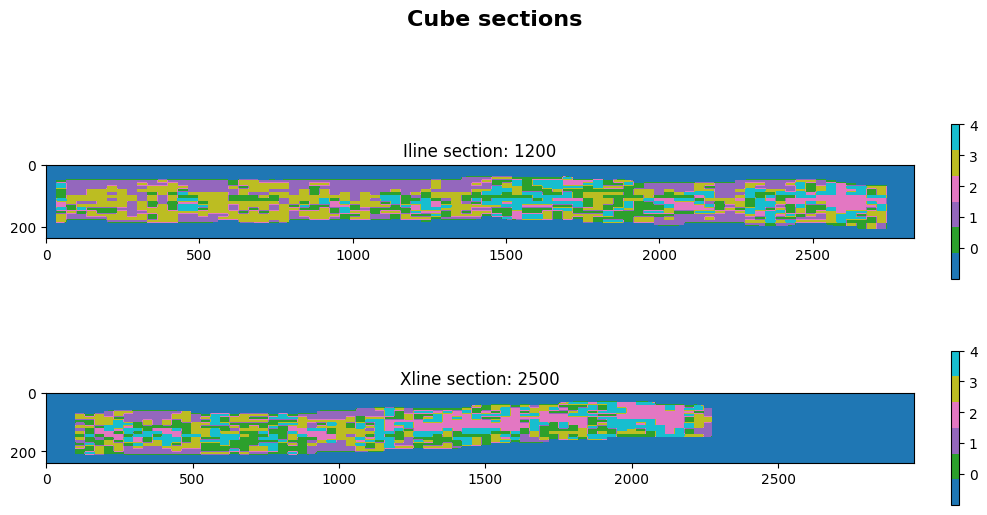

In [41]:
get_section_picture(out_tens_snd_exp)

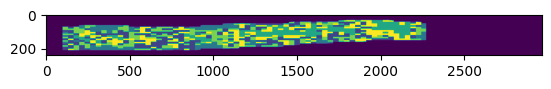

In [21]:
plt.imshow(out_tens_snd_exp[:,2500,:].T)

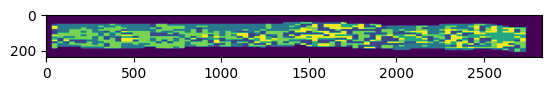

In [15]:
plt.imshow(out_tens_snd_exp[1200,:,:].T)

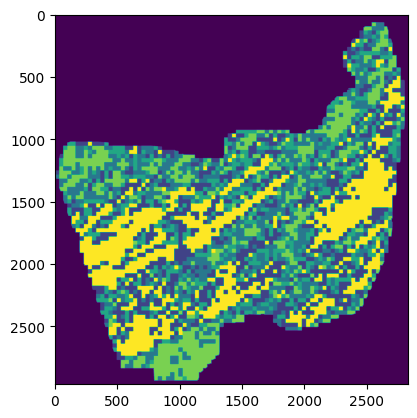

In [11]:
plt.imshow(out_tens[:,:,100])